# Preface

As a NLP beginner, I would like to use this dataset to practice my skills. In this notebook, Naive Bayes is selected as a main model to proceed.

In below notebook, you can also find a practice to the same dataset done in Logistic Regression

https://www.kaggle.com/code/coronatianmao/nlp-beginner-logistic-disaster-tweets-detection

|Version|Score|Comments|
|--|--|--|
|V2|0.79313|It returns a higher score than logistic regression model above in the link, with less effort in this case|


# Loading needed packages

In [1]:
import pdb
from nltk.corpus import stopwords, twitter_samples
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer
import numpy as np
import pandas as pd
import nltk
import string
from nltk.tokenize import TweetTokenizer
from os import getcwd
from wordcloud import WordCloud

nltk.download('twitter_samples')
nltk.download('stopwords')

import re

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[nltk_data] Downloading package twitter_samples to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load some useful functions below

Use below function to process tweet, it would return a list of words

In [2]:
def test_lookup(func):
    freqs = {('sad', 0): 4,
             ('happy', 1): 12,
             ('oppressed', 0): 7}
    word = 'happy'
    label = 1
    if func(freqs, word, label) == 12:
        return 'SUCCESS!!'
    return 'Failed Sanity Check!'


def lookup(freqs, word, label):

    n = 0  # freqs.get((word, label), 0)

    pair = (word, label)
    if (pair in freqs):
        n = freqs[pair]

    return n

def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):

    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [3]:
def process_tweet(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    tweet = re.sub(r'\$\w*', '', tweet)

    tweet = re.sub(r'^RT[\s]+', '', tweet)
  
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)


    tweet = re.sub(r'#', '', tweet)

    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation

            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return tweets_clean

Use below function to build the frequency matrix, in the form of ('word',1/0):number of words

In [4]:
def build_freqs(tweets, ys):
    """Build frequencies.
    Input:
        tweets: a list of tweets
        ys: an m x 1 array with the sentiment label of each tweet
            (either 0 or 1)
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """

    yslist = np.squeeze(ys).tolist()

    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1

    return freqs

# Explore datasets

In [5]:
test = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv').sample(2000,random_state=10)
train = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')

validation = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

In [6]:
#train = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
train_x = train['text'] 
train_y = train['target']

test_x = test['text']
test_y = test['target']

Download stop words list

In [7]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Word cloud

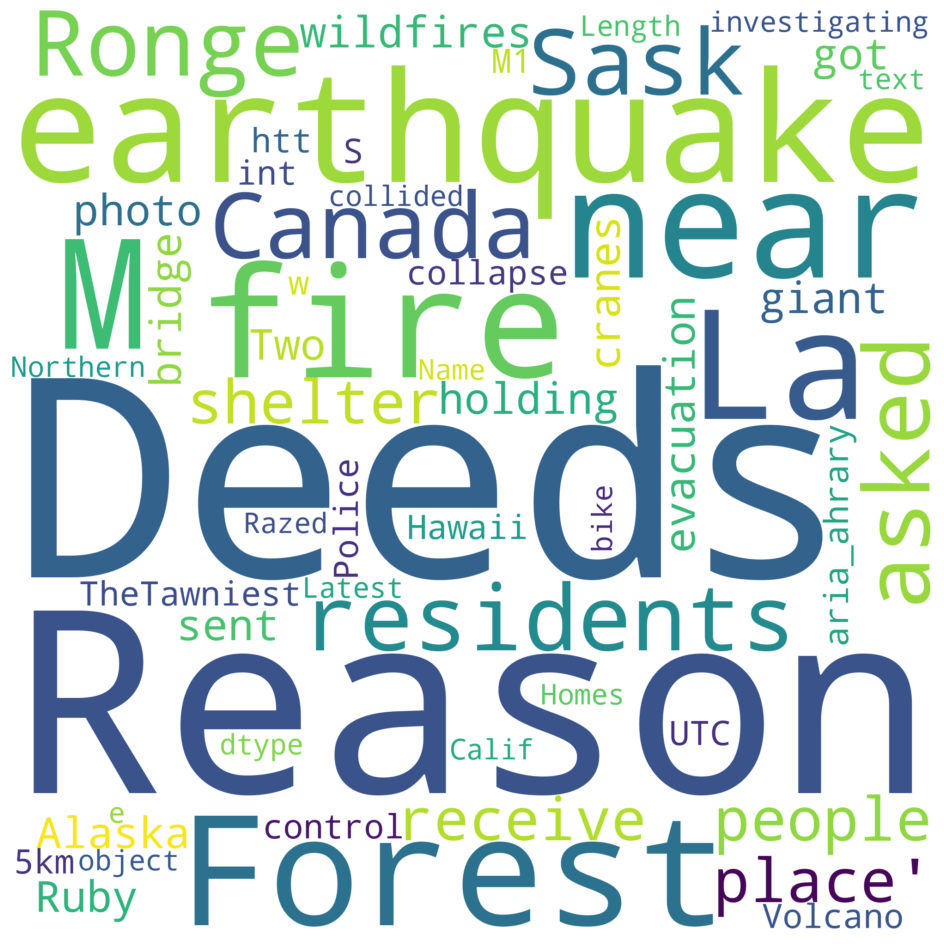

In [8]:
wc = WordCloud(background_color = 'white',
                      height =2000,
                      width = 2000,
                     ).generate(str(train['text']))                                                                                                                        

plt.rcParams['figure.figsize'] = (12,12)
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()
result = wc.to_file("Tweets_word_cloud.png")

# Data preparation

In [9]:
def count_tweets(result, tweets, ys):

    for y, tweet in zip(ys, tweets):
        for word in process_tweet(tweet):
            pair = (word,y)
            
            if pair in result:
                result[pair] += 1

            else:
                result[pair] = 1
    return result

In [10]:
result = {}
tweets = ['i am happy', 'i am tricked', 'i am sad', 'i am tired', 'i am tired']
ys = [1, 0, 0, 0, 0]
count_tweets(result, tweets, ys)

{('happi', 1): 1, ('trick', 0): 1, ('sad', 0): 1, ('tire', 0): 2}

In [11]:
freqs = build_freqs(train_x, train_y)

In [12]:
def train_naive_bayes(freqs, train_x, train_y):

    loglikelihood = {}
    logprior = 0


    vocab = pd.DataFrame(freqs.keys())[0].unique()
    V = len(pd.DataFrame(freqs.keys())[0].unique()) 

    N_pos = N_neg = 0
    for pair in freqs.keys():

        if pair[1] > 0:

            N_pos += freqs[pair]

        else:

            N_neg += freqs[pair]
    
    D = len(train_y)

    D_pos = np.sum(train_y==1)

    D_neg = np.sum(train_y==0)

    logprior = np.log(D_pos)-np.log(D_neg)
    
    for word in vocab:
        freq_pos = freqs.get((word,1),0)
        freq_neg = freqs.get((word,0),0)

        p_w_pos = (freq_pos+1)/(N_pos+V)
        p_w_neg = (freq_neg+1)/(N_neg+V)

        loglikelihood[word] = np.log(p_w_pos)-np.log(p_w_neg)

    return logprior, loglikelihood

In [13]:
logprior, loglikelihood = train_naive_bayes(freqs, train_x, train_y)

In [14]:
def naive_bayes_predict(tweet, logprior, loglikelihood):

    word_l = process_tweet(tweet)

    p = 0

    p += logprior

    for word in word_l:

        if word in loglikelihood:
            p += loglikelihood.get(word,0)

    return p

In [15]:
my_tweet = 'She smiled.'
p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print('The expected output is', p)

The expected output is -2.3722772757689263


In [16]:
my_tweet = 'He laughed.'
p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print('The expected output is', p)

The expected output is -1.7844906108668077


In [17]:
def test_naive_bayes(test_x, test_y, logprior, loglikelihood, naive_bayes_predict=naive_bayes_predict):

    accuracy = 0 

    y_hats = []
    for tweet in test_x:

        if naive_bayes_predict(tweet, logprior, loglikelihood) > 0:

            y_hat_i = 1
        else:

            y_hat_i = 0

        y_hats.append(y_hat_i)

    error = np.average(abs(np.array(y_hats)-np.array(test_y)))
    accuracy = 1-error

    return accuracy

In [18]:
print("Naive Bayes accuracy = %0.4f" %
      (test_naive_bayes(test_x, test_y, logprior, loglikelihood)))

Naive Bayes accuracy = 0.8835


In [19]:
y_hat_list = []
for x in validation['text']:
    # print(x)
    # x_process = process_tweet(x)
    # print(x_process)
    y_hat = naive_bayes_predict(x, logprior, loglikelihood)
    y_hat_list.append(int(y_hat > 0.5))

In [20]:
# create frequency dictionary
#freqs = build_freqs(tweets, labels)

In [21]:
sample_submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")
sample_submission["target"] = pd.DataFrame({'target':y_hat_list})
sample_submission.to_csv("submission.csv", index=False)

<Axes: >

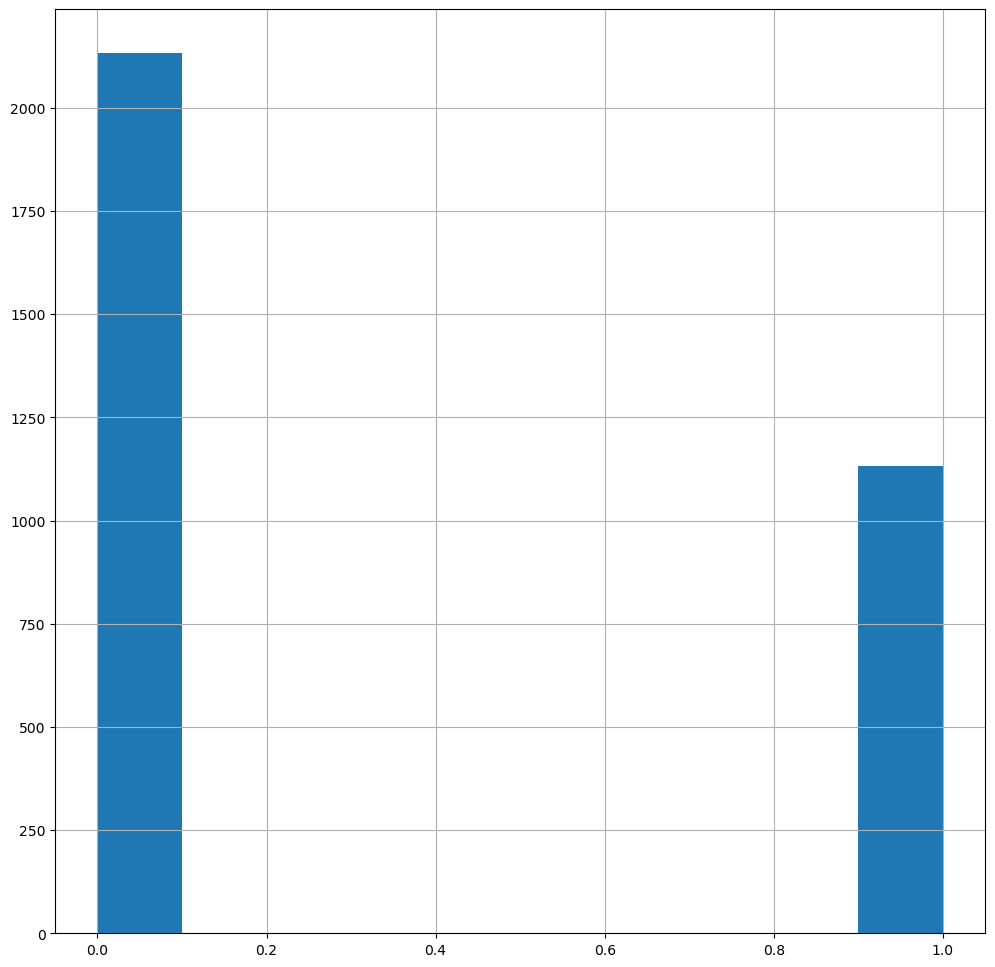

In [22]:
sample_submission.target.hist()